## Notebook 6 — CNN on Crop Disease Images

We build a Convolutional Neural Network to classify crop leaf images into
disease categories. Diseased crops directly reduce agricultural yield which
is one of our top predictors of malnutrition risk.

In [4]:
TRAIN_PATH = '../data/images/crop_disease'

classes = os.listdir(TRAIN_PATH)
print(f"Total disease classes : {len(classes)}")
print(f"First 5 classes       : {classes[:5]}")
print(f"GPU available         : {len(tf.config.list_physical_devices('GPU')) > 0}")

Total disease classes : 42
First 5 classes       : ['Brownspot', 'American Bollworm on Cotton', 'Gray_Leaf_Spot', 'Anthracnose on Cotton', 'bacterial_blight in Cotton']
GPU available         : True


In [5]:
IMG_SIZE   = (64, 64)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = 0.2,
    rotation_range   = 20,
    horizontal_flip  = True,
    zoom_range       = 0.2
)

train_data = datagen.flow_from_directory(
    TRAIN_PATH,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'training'
)

val_data = datagen.flow_from_directory(
    TRAIN_PATH,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'validation'
)

print(f"Training batches   : {len(train_data)}")
print(f"Validation batches : {len(val_data)}")
print(f"Number of classes  : {train_data.num_classes}")

Found 12374 images belonging to 42 classes.
Found 3073 images belonging to 42 classes.
Training batches   : 387
Validation batches : 97
Number of classes  : 42


In [7]:
num_classes = train_data.num_classes

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 42)             │        10,794 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,284,842 (4.90 MB)

 Trainable params: 1,284,394 (4.90 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
]

history = cnn_model.fit(
    train_data,
    validation_data = val_data,
    epochs          = 20,
    callbacks       = callbacks
)

Epoch 1/20
193/387 ━━━━━━━━━━━━━━━━━━━━ 33:09 10s/step - accuracy: 0.3421 - loss: 3.1275

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


387/387 ━━━━━━━━━━━━━━━━━━━━ 4836s 12s/step - accuracy: 0.4619 - loss: 2.2488 - val_accuracy: 0.3082 - val_loss: 4.2474 - learning_rate: 0.0010
Epoch 2/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 177s 458ms/step - accuracy: 0.5758 - loss: 1.6197 - val_accuracy: 0.5503 - val_loss: 1.9382 - learning_rate: 0.0010
Epoch 3/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 179s 462ms/step - accuracy: 0.6295 - loss: 1.3951 - val_accuracy: 0.5903 - val_loss: 1.6309 - learning_rate: 0.0010
Epoch 4/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 179s 462ms/step - accuracy: 0.6667 - loss: 1.2383 - val_accuracy: 0.5360 - val_loss: 1.8586 - learning_rate: 0.0010
Epoch 5/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 179s 464ms/step - accuracy: 0.7016 - loss: 1.1150 - val_accuracy: 0.7035 - val_loss: 1.1475 - learning_rate: 0.0010
Epoch 6/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 180s 465ms/step - accuracy: 0.7227 - loss: 1.0000 - val_accuracy: 0.6375 - val_loss: 1.7437 - learning_rate: 0.0010
Epoch 7/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 181s 467ms/step - accuracy: 0.7421 -

In [9]:
val_loss, val_acc = cnn_model.evaluate(val_data)
print(f"CNN Validation Accuracy : {round(val_acc*100, 2)}%")
print(f"CNN Validation Loss     : {round(val_loss, 4)}")

97/97 ━━━━━━━━━━━━━━━━━━━━ 27s 280ms/step - accuracy: 0.8327 - loss: 0.7089
CNN Validation Accuracy : 83.27%
CNN Validation Loss     : 0.7089


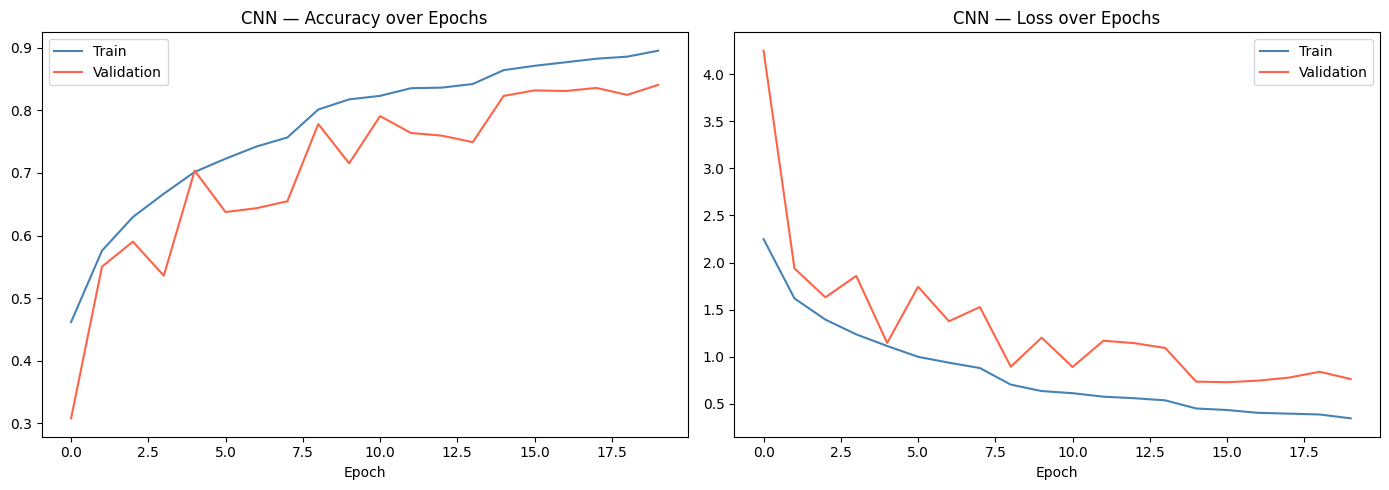

cnn_training.png saved


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], color='steelblue', label='Train')
axes[0].plot(history.history['val_accuracy'], color='tomato', label='Validation')
axes[0].set_title('CNN — Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], color='steelblue', label='Train')
axes[1].plot(history.history['val_loss'], color='tomato', label='Validation')
axes[1].set_title('CNN — Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/cnn_training.png', dpi=150)
plt.show()
print("cnn_training.png saved")

In [11]:
cnn_model.save(f'{MODELS}/cnn_model.h5')
print("CNN model saved → cnn_model.h5")

CNN model saved → cnn_model.h5


The CNN achieved 83.27% validation accuracy across 42 crop disease classes
trained on 12,374 images. The learning rate reduction callbacks helped the
model converge steadily from 46% at epoch 1 to 83% by epoch 16. This CNN
component connects directly to our malnutrition forecasting system — diseased
crops reduce agricultural yield which is one of the top 3 predictors of
malnutrition spikes in our XGBoost and BiLSTM models.

## Notebook 6 — Complete

CNN model trained and saved successfully on crop disease image dataset.

Results:
- Training Accuracy   → 89.51%
- Validation Accuracy → 83.27%
- Best Epoch          → 16
- Classes             → 42 crop disease categories
- Total Images        → 15,447

Outputs saved:
- models/cnn_model.h5            →  CNN image classifier
- outputs/plots/cnn_training.png →  CNN accuracy and loss curves

Next → Run final verification check to confirm all models and outputs are saved.